In [1]:
import numpy as np
import pandas as pd
from IPython.display import display


In [2]:
# -------------------Loading the data ---------------------- #

# TO LOAD A CSV FILE IN PANDAS ---> pd.read_csv('file.csv') || file.csv----> is path of that file

# Currently anime.csv is in the same folder so we just write anime.csv

df = pd.read_csv('anime.csv')
display(df)


,Rank,Title,Score
0,1,Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr...,9.10
1,2,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473...",9.07
2,3,Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 -...,9.06
3,4,"Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 ...",9.06
4,5,Shingeki no Kyojin Season 3 Part 2TV (10 eps)A...,9.05
5,6,"Gintama'TV (51 eps)Apr 2011 - Mar 2012534,105 ...",9.04
6,7,Gintama: The FinalMovie (1 eps)Jan 2021 - Jan ...,9.04
7,8,Hunter x Hunter TV (148 eps)Oct 2011 - Sep 201...,9.04
8,9,Kaguya-sama wa Kokurasetai: Ultra RomanticTV (...,9.04
9,10,Gintama': EnchousenTV (13 eps)Oct 2012 - Mar 2...,9.03


In [3]:
#----------------ONLY VIEW FIRST 5 ROWS-------------------#

df.head() # function to view top 5 rows ..

,Rank,Title,Score
0,1,Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr...,9.10
1,2,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473...",9.07
2,3,Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 -...,9.06
3,4,"Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 ...",9.06
4,5,Shingeki no Kyojin Season 3 Part 2TV (10 eps)A...,9.05


In [4]:
#---------------------QUESTI0NS----------------------#

# 1--> make a new column for episode count
# 2--> make a new column for time stamp
# 3--> which anime has the highest score
# 4--> give me top 5 highest scoring anime
# 5--> which anime has the highest episode count
# 6--> animes with top 5 episode count
# 7--> which is the longest running anime



In [5]:
#----------------------------------------Q:1------------------------------------------------------#

#----------------WHAT IS FEATURE EXTRACTION--------------#

# NOW , here we can see there are many analytics based on episode count so 
# why not make a column for episode count itself as it is used directly
# but there is no feature for episode count so we need to extract it from title which has ep count indirectly
# this is called feature extraction , as we onoy have 3 features right now for analytics rank , title ,score


In [6]:

#---------------PATTERN---------------#

display(df.loc[1]) # we only need title to extract out feature 'ep count' 
print("\nTitle format : ")
display(df.loc[1]['Title'])

print("\nTitle format : ")
display(df.loc[3]['Title'])

print("\nTitle format : ")
display(df.loc[45]['Title'])

# notice the format episode count is always in brackets ..

Rank                                                     2
Title    Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473...
Score                                                 9.07
Name: 1, dtype: object


Title format : 


'Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473,707 members'


Title format : 


'Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 members'


Title format : 


'Vinland SagaTV (24 eps)Jul 2019 - Dec 20191,403,669 membersManga StoreVolume 1€17.99Preview'

In [7]:
#------------EXTRACTION FUNCTION DEBUGGING-------------#

def extract_episode_count(title):
    
    start = title.find('(')
    end   = title.find(' eps)')
    print(f"\nstart : {start}, end : {end} ")
          
    # slice the string :
    number_part_title_as_string = title[start:end]
    print("extracted part as a string :" ,number_part_title_as_string)

    # corrected slicing :
    number_part_title_as_string = title[start+1:end]
    print("corrected extracted part as a string   : ",number_part_title_as_string, type(number_part_title_as_string))

    # convert it into integer : 
    count_episode = int(number_part_title_as_string)
    print("corrected extracted part as an integer : ",count_episode,type(count_episode))

    return count_episode


# Test it manually before parsing
print("\nEpisode count = " , extract_episode_count(df.loc[1]['Title']))
print("\nEpisode count = " , extract_episode_count(df.loc[2]['Title']))
print("\nEpisode count = " , extract_episode_count(df.loc[3]['Title']))
print("\nEpisode count = " , extract_episode_count(df.loc[33]['Title']))
print("\nEpisode count = " , extract_episode_count(df.loc[10]['Title']))
print("\nEpisode count = " , extract_episode_count(df.loc[12]['Title']))
print("\nEpisode count = " , extract_episode_count(df.loc[45]['Title']))


start : 14, end : 17 
extracted part as a string : (24
corrected extracted part as a string   :  24 <class 'str'>
corrected extracted part as an integer :  24 <class 'int'>

Episode count =  24

start : 28, end : 31 
extracted part as a string : (13
corrected extracted part as a string   :  13 <class 'str'>
corrected extracted part as an integer :  13 <class 'int'>

Episode count =  13

start : 11, end : 14 
extracted part as a string : (51
corrected extracted part as a string   :  51 <class 'str'>
corrected extracted part as an integer :  51 <class 'int'>

Episode count =  51

start : 20, end : 23 
extracted part as a string : (13
corrected extracted part as a string   :  13 <class 'str'>
corrected extracted part as an integer :  13 <class 'int'>

Episode count =  13

start : 59, end : 61 
extracted part as a string : (2
corrected extracted part as a string   :  2 <class 'str'>
corrected extracted part as an integer :  2 <class 'int'>

Episode count =  2

start : 45, end : 48 
extrac

In [8]:
#------------------TESTING A NEW COLUMN NOW AS FUNCTION TO APPLY WORKS--------------#

# Now function is working so to apply that function we use df.apply

# To avoid multiple lines printing for every call we ENHANCE THE EXISTING FUNCTION so nothing gets printed

def extract_episode_count(title):
    start = title.find('(')
    end = title.find(' eps)')

    if (start==(-1)) or (end==(-1)) :
        return None
    
    count_part = title[start+1:end]

    return int(count_part)
    
df['Episode_Count'] = df['Title'].apply(extract_episode_count)

display(df.head())

df.info() 
# we can see for every 50 episode ep_count has datatype integer(int64) and non null ,
# so NO NULL VALUES of episode_count to replace for any title ...



,Rank,Title,Score,Episode_Count
0,1,Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr...,9.10,64
1,2,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473...",9.07,24
2,3,Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 -...,9.06,13
3,4,"Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 ...",9.06,51
4,5,Shingeki no Kyojin Season 3 Part 2TV (10 eps)A...,9.05,10


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Rank           50 non-null     int64  
 1   Title          50 non-null     object 
 2   Score          50 non-null     float64
 3   Episode_Count  50 non-null     int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 1.7+ KB


In [9]:
# --------VIEW FIRST 20 ROWS TO CHECK IF FEATURE EXTRACTION WORKED----------#

threshold  = np.arange(0,20)
display(threshold)

display(df.loc[threshold])

df.info()


array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19])

,Rank,Title,Score,Episode_Count
0,1,Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr...,9.10,64
1,2,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473...",9.07,24
2,3,Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 -...,9.06,13
3,4,"Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 ...",9.06,51
4,5,Shingeki no Kyojin Season 3 Part 2TV (10 eps)A...,9.05,10
5,6,"Gintama'TV (51 eps)Apr 2011 - Mar 2012534,105 ...",9.04,51
6,7,Gintama: The FinalMovie (1 eps)Jan 2021 - Jan ...,9.04,1
7,8,Hunter x Hunter TV (148 eps)Oct 2011 - Sep 201...,9.04,148
8,9,Kaguya-sama wa Kokurasetai: Ultra RomanticTV (...,9.04,13
9,10,Gintama': EnchousenTV (13 eps)Oct 2012 - Mar 2...,9.03,13


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Rank           50 non-null     int64  
 1   Title          50 non-null     object 
 2   Score          50 non-null     float64
 3   Episode_Count  50 non-null     int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 1.7+ KB


In [10]:
#----------VIEWING WHOLE DATAFRAME ------------#
display(df)

,Rank,Title,Score,Episode_Count
0,1,Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr...,9.10,64
1,2,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473...",9.07,24
2,3,Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 -...,9.06,13
3,4,"Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 ...",9.06,51
4,5,Shingeki no Kyojin Season 3 Part 2TV (10 eps)A...,9.05,10
5,6,"Gintama'TV (51 eps)Apr 2011 - Mar 2012534,105 ...",9.04,51
6,7,Gintama: The FinalMovie (1 eps)Jan 2021 - Jan ...,9.04,1
7,8,Hunter x Hunter TV (148 eps)Oct 2011 - Sep 201...,9.04,148
8,9,Kaguya-sama wa Kokurasetai: Ultra RomanticTV (...,9.04,13
9,10,Gintama': EnchousenTV (13 eps)Oct 2012 - Mar 2...,9.03,13


In [11]:

#-------------------------------------Q:2-------------------------------------------#


In [12]:
#-----------UNDERSTANDING PATTERN------------#

# MAKE A NEW COLUMN FOR TIMESTAMP

display(df.loc[[1,2,3]]['Title'])

# Not able to view full title texts so set the limit to none by using a new function

pd.set_option('display.max_colwidth',None)

display(df.loc[[1,2,3,33,44,24,37]]['Title'])

# We can see start date starts after ) everytime and ends before '-' (dash) so lets extract start first 

1    Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473...
2    Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 -...
3    Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 ...
Name: Title, dtype: object

1                 Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473,707 members
2     Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 - Dec 2022474,138 members
3                      Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 members
33          Mob Psycho 100 IITV (13 eps)Jan 2019 - Apr 20191,458,089 members
44            Kingdom 4th SeasonTV (26 eps)Apr 2022 - Oct 202255,833 members
24                    MonsterTV (74 eps)Apr 2004 - Sep 20051,041,081 members
37                 "Oshi no Ko"TV (11 eps)Apr 2023 - Jun 2023645,856 members
Name: Title, dtype: object

In [13]:
#-----------------START DATE EXTRACTION DEBUGGING----------#

def get_start_month(title):

    start = title.find(')')
    end   = title.find(' members')

    print("\nStart Index : ",start)
    print("End Index   : ", end)

    start_timestamp = title[start:end]

    print("Extracted start date           : ",start_timestamp)

    # corrected part now : 
    start_timestamp = title[start+1:end]
    print("Corrected Extracted start date : ",start_timestamp,type(start_timestamp))
    

    # removing trailing/leading spaces 
    start_timestamp = start_timestamp.strip()

    parts = start_timestamp.split(' ')
    print(parts)
    
    start_month = parts[0]
    start_year  = int(parts[1])
    print("Start Month : ", start_month , type(start_month))
    print("Start Year  : ",start_year , type(start_year))

    return start_month
    
# Test it manually....
df.loc[[1,2,30,41,17]]['Title'].apply(get_start_month)


Start Index :  21
End Index   :  50
Extracted start date           :  )Apr 2011 - Sep 20112,473,707
Corrected Extracted start date :  Apr 2011 - Sep 20112,473,707 <class 'str'>
['Apr', '2011', '-', 'Sep', '20112,473,707']
Start Month :  Apr <class 'str'>
Start Year  :  2011 <class 'int'>

Start Index :  35
End Index   :  62
Extracted start date           :  )Oct 2022 - Dec 2022474,138
Corrected Extracted start date :  Oct 2022 - Dec 2022474,138 <class 'str'>
['Oct', '2022', '-', 'Dec', '2022474,138']
Start Month :  Oct <class 'str'>
Start Year  :  2022 <class 'int'>

Start Index :  35
End Index   :  63
Extracted start date           :  )Jul 2023 - Aug 2023 556,301
Corrected Extracted start date :  Jul 2023 - Aug 2023 556,301 <class 'str'>
['Jul', '2023', '-', 'Aug', '2023', '556,301']
Start Month :  Jul <class 'str'>
Start Year  :  2023 <class 'int'>

Start Index :  53
End Index   :  82
Extracted start date           :  )Jan 2022 - Apr 20221,170,165
Corrected Extracted start date :  J

1     Apr
2     Oct
30    Jul
41    Jan
17    Oct
Name: Title, dtype: object

In [14]:
#------------------------------CREATING START MONTH COLUMN----------------#

#-----CREATING NEW FUNCITON REMOVING PRINTED LINES USED FOR DEBUGGING-----#


def get_start_month(title):
    
    start = title.find(')')
    end   = title.find(' members')
    

    start_timestamp = title[start+1:end]

    start_timestamp = start_timestamp.strip() # removing leading trailing spaces..

    parts = start_timestamp.split(' ')
    
    start_month = parts[0]
    start_year  = int(parts[1])

    return start_month

df['Start_Month'] = df['Title'].apply(get_start_month)


In [15]:
#----------VIEWING TOP 20 ROWS TO VERIFY-------------#

threshold = np.arange(0,20)
display(df.head())
display(df.info())
display(df.loc[threshold])

,Rank,Title,Score,Episode_Count,Start_Month
0,1,"Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr 2009 - Jul 20103,218,472 membersManga StoreVolume 1€4.58Preview",9.10,64,Apr
1,2,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473,707 members",9.07,24,Apr
2,3,"Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 - Dec 2022474,138 members",9.06,13,Oct
3,4,"Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 members",9.06,51,Apr
4,5,"Shingeki no Kyojin Season 3 Part 2TV (10 eps)Apr 2019 - Jul 20192,146,679 membersManga StoreVolume 1€10.99Preview",9.05,10,Apr


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Rank           50 non-null     int64  
 1   Title          50 non-null     object 
 2   Score          50 non-null     float64
 3   Episode_Count  50 non-null     int64  
 4   Start_Month    50 non-null     object 
dtypes: float64(1), int64(2), object(2)
memory usage: 2.1+ KB


None

,Rank,Title,Score,Episode_Count,Start_Month
0,1,"Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr 2009 - Jul 20103,218,472 membersManga StoreVolume 1€4.58Preview",9.10,64,Apr
1,2,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473,707 members",9.07,24,Apr
2,3,"Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 - Dec 2022474,138 members",9.06,13,Oct
3,4,"Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 members",9.06,51,Apr
4,5,"Shingeki no Kyojin Season 3 Part 2TV (10 eps)Apr 2019 - Jul 20192,146,679 membersManga StoreVolume 1€10.99Preview",9.05,10,Apr
5,6,"Gintama'TV (51 eps)Apr 2011 - Mar 2012534,105 members",9.04,51,Apr
6,7,"Gintama: The FinalMovie (1 eps)Jan 2021 - Jan 2021137,208 members",9.04,1,Jan
7,8,"Hunter x Hunter TV (148 eps)Oct 2011 - Sep 20142,701,154 members",9.04,148,Oct
8,9,"Kaguya-sama wa Kokurasetai: Ultra RomanticTV (13 eps)Apr 2022 - Jun 2022851,445 members",9.04,13,Apr
9,10,"Gintama': EnchousenTV (13 eps)Oct 2012 - Mar 2013313,446 members",9.03,13,Oct


In [16]:
#---------------------START YEAR COLUMN TO ADD-----------------------------#

def get_start_year(title):
    
    start = title.find(')')
    end   = title.find(' members')
    

    start_timestamp = title[start+1:end]

    start_timestamp = start_timestamp.strip() # removing leading trailing spaces..

    parts = start_timestamp.split(' ')
    
    start_month = parts[0]
    start_year  = int(parts[1])

    return start_year 

display(df.loc[[1,14,38,42]]['Title'].apply(get_start_year))
display(df.loc[[1,14,38,42]]['Title'])

1     2011
14    2017
38    2016
42    2000
Name: Title, dtype: int64

1                                                   Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473,707 members
14                                                       Gintama.TV (12 eps)Jan 2017 - Mar 2017302,232 members
38    Haikyuu!! Karasuno Koukou vs. Shiratorizawa Gakuen KoukouTV (10 eps)Oct 2016 - Dec 20161,157,497 members
42                                                 Hajime no IppoTV (75 eps)Oct 2000 - Mar 2002558,435 members
Name: Title, dtype: object

In [17]:
#---------VIEWING FIRST 20 ROWS TO VERIFY------------#

df['Start_Year'] = df['Title'].apply(get_start_year)
threshold = np.arange(0,20)
display(df.loc[threshold])

,Rank,Title,Score,Episode_Count,Start_Month,Start_Year
0,1,"Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr 2009 - Jul 20103,218,472 membersManga StoreVolume 1€4.58Preview",9.10,64,Apr,2009
1,2,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473,707 members",9.07,24,Apr,2011
2,3,"Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 - Dec 2022474,138 members",9.06,13,Oct,2022
3,4,"Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 members",9.06,51,Apr,2015
4,5,"Shingeki no Kyojin Season 3 Part 2TV (10 eps)Apr 2019 - Jul 20192,146,679 membersManga StoreVolume 1€10.99Preview",9.05,10,Apr,2019
5,6,"Gintama'TV (51 eps)Apr 2011 - Mar 2012534,105 members",9.04,51,Apr,2011
6,7,"Gintama: The FinalMovie (1 eps)Jan 2021 - Jan 2021137,208 members",9.04,1,Jan,2021
7,8,"Hunter x Hunter TV (148 eps)Oct 2011 - Sep 20142,701,154 members",9.04,148,Oct,2011
8,9,"Kaguya-sama wa Kokurasetai: Ultra RomanticTV (13 eps)Apr 2022 - Jun 2022851,445 members",9.04,13,Apr,2022
9,10,"Gintama': EnchousenTV (13 eps)Oct 2012 - Mar 2013313,446 members",9.03,13,Oct,2012


In [18]:
#----------VIEWING ALL------------#

display(df)

,Rank,Title,Score,Episode_Count,Start_Month,Start_Year
0,1,"Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr 2009 - Jul 20103,218,472 membersManga StoreVolume 1€4.58Preview",9.10,64,Apr,2009
1,2,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473,707 members",9.07,24,Apr,2011
2,3,"Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 - Dec 2022474,138 members",9.06,13,Oct,2022
3,4,"Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 members",9.06,51,Apr,2015
4,5,"Shingeki no Kyojin Season 3 Part 2TV (10 eps)Apr 2019 - Jul 20192,146,679 membersManga StoreVolume 1€10.99Preview",9.05,10,Apr,2019
5,6,"Gintama'TV (51 eps)Apr 2011 - Mar 2012534,105 members",9.04,51,Apr,2011
6,7,"Gintama: The FinalMovie (1 eps)Jan 2021 - Jan 2021137,208 members",9.04,1,Jan,2021
7,8,"Hunter x Hunter TV (148 eps)Oct 2011 - Sep 20142,701,154 members",9.04,148,Oct,2011
8,9,"Kaguya-sama wa Kokurasetai: Ultra RomanticTV (13 eps)Apr 2022 - Jun 2022851,445 members",9.04,13,Apr,2022
9,10,"Gintama': EnchousenTV (13 eps)Oct 2012 - Mar 2013313,446 members",9.03,13,Oct,2012


In [19]:
#---------------------EXTRACTING END MONTH-------------------#

#------UNDERSTANDING PATTERN-----------#

display(df.loc[[1,11,21,31,41]])

# we can see end timestamp starts after dash and 
# ends 6 digits before ' members' 

,Rank,Title,Score,Episode_Count,Start_Month,Start_Year
1,2,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473,707 members",9.07,24,Apr,2011
11,12,"Ginga Eiyuu DensetsuOVA (110 eps)Jan 1988 - Mar 1997309,193 members",9.02,110,Jan,1988
21,22,"Violet Evergarden MovieMovie (1 eps)Sep 2020 - Sep 2020564,225 members",8.89,1,Sep,2020
31,32,"Gintama.: Shirogane no Tamashii-henTV (12 eps)Jan 2018 - Mar 2018203,540 members",8.81,12,Jan,2018
41,42,"Shingeki no Kyojin: The Final Season Part 2TV (12 eps)Jan 2022 - Apr 20221,170,165 membersManga StoreVolume 1€10.99Preview",8.77,12,Jan,2022


In [20]:
#--------------------END TIMESTAMP DEBUGGING------------------------#


def get_time_year(title):

    start = title.find(')')
    end   = title.find(' members')

    time_stamp = title[start:end]
    print("time_stamp           : ",time_stamp)

    time_stamp = title[start+1:end-7]
    print("Corrected Time Stamp : ",time_stamp)
    

    parts = time_stamp.strip() # removing leading / trailing spaces
    parts = time_stamp.split(' ')
    # for end year we have to slice part[4] to first 4 characters 
    parts[4] = parts[4][0:4]
    print("Parts: ",parts)
    print("\n")

    
    return parts[4]
    

threshold = np.arange(0,11)
display(df.loc[threshold]['Title'].apply(get_time_year))

time_stamp           :  )Apr 2009 - Jul 20103,218,472
Corrected Time Stamp :  Apr 2009 - Jul 20103,
Parts:  ['Apr', '2009', '-', 'Jul', '2010']


time_stamp           :  )Apr 2011 - Sep 20112,473,707
Corrected Time Stamp :  Apr 2011 - Sep 20112,
Parts:  ['Apr', '2011', '-', 'Sep', '2011']


time_stamp           :  )Oct 2022 - Dec 2022474,138
Corrected Time Stamp :  Oct 2022 - Dec 2022
Parts:  ['Oct', '2022', '-', 'Dec', '2022']


time_stamp           :  )Apr 2015 - Mar 2016605,113
Corrected Time Stamp :  Apr 2015 - Mar 2016
Parts:  ['Apr', '2015', '-', 'Mar', '2016']


time_stamp           :  )Apr 2019 - Jul 20192,146,679
Corrected Time Stamp :  Apr 2019 - Jul 20192,
Parts:  ['Apr', '2019', '-', 'Jul', '2019']


time_stamp           :  )Apr 2011 - Mar 2012534,105
Corrected Time Stamp :  Apr 2011 - Mar 2012
Parts:  ['Apr', '2011', '-', 'Mar', '2012']


time_stamp           :  )Jan 2021 - Jan 2021137,208
Corrected Time Stamp :  Jan 2021 - Jan 2021
Parts:  ['Jan', '2021', '-', 'Jan', '202

0     2010
1     2011
2     2022
3     2016
4     2019
5     2012
6     2021
7     2014
8     2022
9     2013
10    2023
Name: Title, dtype: object

In [21]:
#-----------------CREATING NEW COLUMN FOR END YEAR-----------#

#-------Removing prints for calling every row of dataframe----------#

def get_time_year(title):

    start = title.find(')')
    end   = title.find(' members')

    time_stamp = title[start:end]
    

    time_stamp = title[start+1:end-7]
    

    parts = time_stamp.strip() # removing leading / trailing spaces
    parts = time_stamp.split(' ')
    # for end year we have to slice part[4] to first 4 characters 
    parts[4] = int(parts[4][0:4])

    
    return parts[4]

df['End_Year'] = df['Title'].apply(get_time_year)

df.head()

,Rank,Title,Score,Episode_Count,Start_Month,Start_Year,End_Year
0,1,"Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr 2009 - Jul 20103,218,472 membersManga StoreVolume 1€4.58Preview",9.10,64,Apr,2009,2010
1,2,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473,707 members",9.07,24,Apr,2011,2011
2,3,"Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 - Dec 2022474,138 members",9.06,13,Oct,2022,2022
3,4,"Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 members",9.06,51,Apr,2015,2016
4,5,"Shingeki no Kyojin Season 3 Part 2TV (10 eps)Apr 2019 - Jul 20192,146,679 membersManga StoreVolume 1€10.99Preview",9.05,10,Apr,2019,2019


In [22]:
#----------VIEWING FIRST 20 COLUMNS----------#

threshold = np.arange(0,20)
df.loc[threshold]



,Rank,Title,Score,Episode_Count,Start_Month,Start_Year,End_Year
0,1,"Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr 2009 - Jul 20103,218,472 membersManga StoreVolume 1€4.58Preview",9.10,64,Apr,2009,2010
1,2,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473,707 members",9.07,24,Apr,2011,2011
2,3,"Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 - Dec 2022474,138 members",9.06,13,Oct,2022,2022
3,4,"Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 members",9.06,51,Apr,2015,2016
4,5,"Shingeki no Kyojin Season 3 Part 2TV (10 eps)Apr 2019 - Jul 20192,146,679 membersManga StoreVolume 1€10.99Preview",9.05,10,Apr,2019,2019
5,6,"Gintama'TV (51 eps)Apr 2011 - Mar 2012534,105 members",9.04,51,Apr,2011,2012
6,7,"Gintama: The FinalMovie (1 eps)Jan 2021 - Jan 2021137,208 members",9.04,1,Jan,2021,2021
7,8,"Hunter x Hunter TV (148 eps)Oct 2011 - Sep 20142,701,154 members",9.04,148,Oct,2011,2014
8,9,"Kaguya-sama wa Kokurasetai: Ultra RomanticTV (13 eps)Apr 2022 - Jun 2022851,445 members",9.04,13,Apr,2022,2022
9,10,"Gintama': EnchousenTV (13 eps)Oct 2012 - Mar 2013313,446 members",9.03,13,Oct,2012,2013


In [23]:
#-----------VIEWING COMPLETE DATAFRAME--------#
display(df)

,Rank,Title,Score,Episode_Count,Start_Month,Start_Year,End_Year
0,1,"Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr 2009 - Jul 20103,218,472 membersManga StoreVolume 1€4.58Preview",9.10,64,Apr,2009,2010
1,2,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473,707 members",9.07,24,Apr,2011,2011
2,3,"Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 - Dec 2022474,138 members",9.06,13,Oct,2022,2022
3,4,"Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 members",9.06,51,Apr,2015,2016
4,5,"Shingeki no Kyojin Season 3 Part 2TV (10 eps)Apr 2019 - Jul 20192,146,679 membersManga StoreVolume 1€10.99Preview",9.05,10,Apr,2019,2019
5,6,"Gintama'TV (51 eps)Apr 2011 - Mar 2012534,105 members",9.04,51,Apr,2011,2012
6,7,"Gintama: The FinalMovie (1 eps)Jan 2021 - Jan 2021137,208 members",9.04,1,Jan,2021,2021
7,8,"Hunter x Hunter TV (148 eps)Oct 2011 - Sep 20142,701,154 members",9.04,148,Oct,2011,2014
8,9,"Kaguya-sama wa Kokurasetai: Ultra RomanticTV (13 eps)Apr 2022 - Jun 2022851,445 members",9.04,13,Apr,2022,2022
9,10,"Gintama': EnchousenTV (13 eps)Oct 2012 - Mar 2013313,446 members",9.03,13,Oct,2012,2013


In [24]:
#--------------EXTRACTING END MONTH DEBUGING--------------#

def get_end_month(title):

    start = title.find(')')
    end   = title.find(' members')

    time_stamp = title[start:end]
    

    time_stamp = title[start+1:end-7]
    

    parts = time_stamp.strip() # removing leading / trailing spaces
    parts = time_stamp.split(' ')
    # for end year we have to slice part[4] to first 4 characters 
    parts[4] = parts[4][0:4]

    
    return parts[3]

df.loc[[1,2,3,4,5,32,42]]['Title'].apply(get_end_month)

# df['End_Month'] = df['Title'].apply(get_end_month)

1     Sep
2     Dec
3     Mar
4     Jul
5     Mar
32    Oct
42    Mar
Name: Title, dtype: object

In [25]:
#------------------APPLYING FUNCTION------------------#

df['End_Month'] = df['Title'].apply(get_end_month)
df.head()


,Rank,Title,Score,Episode_Count,Start_Month,Start_Year,End_Year,End_Month
0,1,"Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr 2009 - Jul 20103,218,472 membersManga StoreVolume 1€4.58Preview",9.10,64,Apr,2009,2010,Jul
1,2,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473,707 members",9.07,24,Apr,2011,2011,Sep
2,3,"Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 - Dec 2022474,138 members",9.06,13,Oct,2022,2022,Dec
3,4,"Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 members",9.06,51,Apr,2015,2016,Mar
4,5,"Shingeki no Kyojin Season 3 Part 2TV (10 eps)Apr 2019 - Jul 20192,146,679 membersManga StoreVolume 1€10.99Preview",9.05,10,Apr,2019,2019,Jul


In [26]:
# 3--> which anime has the highest score
# 4--> give me top 5 highest scoring anime
# 5--> which anime has the highest episode count
# 6--> animes with top 5 episode count
# 7--> which is the longest running anime
# 8--> Pace of Anime active releases per month 

In [27]:
#--------------------Q:3---------------------#

# highest score for any anime

max_score = df['Score'].max()
display(max_score)

# which index had the highest score 

# ( first index with score 9.1 will be here )
# if there are many anime with score as max score ALL OF THEM WILL NOT BE SHOWN BY THIS...
max_score_index = df['Score'].idxmax(axis=0)
display(max_score_index)

# row with the max_index i.e max score
max_score_row = df.loc[[max_score_index]]
display(max_score_row)





np.float64(9.1)

0

,Rank,Title,Score,Episode_Count,Start_Month,Start_Year,End_Year,End_Month
0,1,"Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr 2009 - Jul 20103,218,472 membersManga StoreVolume 1€4.58Preview",9.1,64,Apr,2009,2010,Jul


In [28]:
#------------------------Q:4-------------------------------------#

# here first appearance of 9.1 is shown for multiple anime with same max score ( rank 1) we use sorting 
df_sorted_by_score = df.sort_values(by='Score',ascending=False)
display(df_sorted_by_score.head(10)) # top 10 by score 




,Rank,Title,Score,Episode_Count,Start_Month,Start_Year,End_Year,End_Month
0,1,"Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr 2009 - Jul 20103,218,472 membersManga StoreVolume 1€4.58Preview",9.10,64,Apr,2009,2010,Jul
1,2,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473,707 members",9.07,24,Apr,2011,2011,Sep
2,3,"Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 - Dec 2022474,138 members",9.06,13,Oct,2022,2022,Dec
3,4,"Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 members",9.06,51,Apr,2015,2016,Mar
4,5,"Shingeki no Kyojin Season 3 Part 2TV (10 eps)Apr 2019 - Jul 20192,146,679 membersManga StoreVolume 1€10.99Preview",9.05,10,Apr,2019,2019,Jul
5,6,"Gintama'TV (51 eps)Apr 2011 - Mar 2012534,105 members",9.04,51,Apr,2011,2012,Mar
6,7,"Gintama: The FinalMovie (1 eps)Jan 2021 - Jan 2021137,208 members",9.04,1,Jan,2021,2021,Jan
7,8,"Hunter x Hunter TV (148 eps)Oct 2011 - Sep 20142,701,154 members",9.04,148,Oct,2011,2014,Sep
8,9,"Kaguya-sama wa Kokurasetai: Ultra RomanticTV (13 eps)Apr 2022 - Jun 2022851,445 members",9.04,13,Apr,2022,2022,Jun
9,10,"Gintama': EnchousenTV (13 eps)Oct 2012 - Mar 2013313,446 members",9.03,13,Oct,2012,2013,Mar


In [29]:
# View title and score of top 5 anime by score...
df_sorted_by_score = df.sort_values(by='Score',ascending=False)
display(df_sorted_by_score[['Title','Score']].head(5))

display(df.head(5))

,Title,Score
0,"Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr 2009 - Jul 20103,218,472 membersManga StoreVolume 1€4.58Preview",9.10
1,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473,707 members",9.07
2,"Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 - Dec 2022474,138 members",9.06
3,"Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 members",9.06
4,"Shingeki no Kyojin Season 3 Part 2TV (10 eps)Apr 2019 - Jul 20192,146,679 membersManga StoreVolume 1€10.99Preview",9.05


,Rank,Title,Score,Episode_Count,Start_Month,Start_Year,End_Year,End_Month
0,1,"Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr 2009 - Jul 20103,218,472 membersManga StoreVolume 1€4.58Preview",9.10,64,Apr,2009,2010,Jul
1,2,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473,707 members",9.07,24,Apr,2011,2011,Sep
2,3,"Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 - Dec 2022474,138 members",9.06,13,Oct,2022,2022,Dec
3,4,"Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 members",9.06,51,Apr,2015,2016,Mar
4,5,"Shingeki no Kyojin Season 3 Part 2TV (10 eps)Apr 2019 - Jul 20192,146,679 membersManga StoreVolume 1€10.99Preview",9.05,10,Apr,2019,2019,Jul


In [30]:
#----------------------Q:5--------------------------#

# what is highest episode count of any anime..
max_episode_count = df['Episode_Count'].max()
display(max_episode_count)
print("\n")

# what is row index of anime with highest episode count ..
max_count_index = df['Episode_Count'].idxmax()
display(max_count_index)
print("\n")

# Row with the maximum episode count 
display(df.loc[[max_count_index]])

print("\n")
# View title score and episode count of anime with highest episode count ..
display(df[['Title','Score','Episode_Count']].loc[[max_count_index]])

np.int64(201)

15

,Rank,Title,Score,Episode_Count,Start_Month,Start_Year,End_Year,End_Month
15,16,"GintamaTV (201 eps)Apr 2006 - Mar 20101,034,418 members",8.94,201,Apr,2006,2010,Mar


,Title,Score,Episode_Count
15,"GintamaTV (201 eps)Apr 2006 - Mar 20101,034,418 members",8.94,201


In [31]:

# we can see start year and end year are 50 integers with no null values to take care of 
# and start month and end month to map via month map to calculate month difference

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Rank           50 non-null     int64  
 1   Title          50 non-null     object 
 2   Score          50 non-null     float64
 3   Episode_Count  50 non-null     int64  
 4   Start_Month    50 non-null     object 
 5   Start_Year     50 non-null     int64  
 6   End_Year       50 non-null     int64  
 7   End_Month      50 non-null     object 
dtypes: float64(1), int64(4), object(3)
memory usage: 3.3+ KB


In [32]:
#-------------------------Q:6---------------------------#

# for longest running anime we need to find period in months 
# for period in months we create a new column for period... so lets create function


# now we called df['New Column'] = df['Title'].apply(function_name) here we need to send 4 columns at once
# which are start year || end year || start month || end month so when we need two attributes to derive new
# attribute we will pass the whole row at once and access multiple atributes within the function...


month_map = {
    'jan': 1, 
    'feb': 2, 
    'mar': 3,
    'apr': 4, 
    'may': 5,
    'jun': 6,
    'jul': 7,
    'aug': 8, 
    'sep': 9, 
    'oct': 10,
    'nov': 11, 
    'dec': 12
}    
df.head()

,Rank,Title,Score,Episode_Count,Start_Month,Start_Year,End_Year,End_Month
0,1,"Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr 2009 - Jul 20103,218,472 membersManga StoreVolume 1€4.58Preview",9.10,64,Apr,2009,2010,Jul
1,2,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473,707 members",9.07,24,Apr,2011,2011,Sep
2,3,"Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 - Dec 2022474,138 members",9.06,13,Oct,2022,2022,Dec
3,4,"Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 members",9.06,51,Apr,2015,2016,Mar
4,5,"Shingeki no Kyojin Season 3 Part 2TV (10 eps)Apr 2019 - Jul 20192,146,679 membersManga StoreVolume 1€10.99Preview",9.05,10,Apr,2019,2019,Jul


In [33]:
#----------------FUNCTION DEBUGGING TO CALCULATE TOTAL PERIOD---------------#

def get_total_period(row):

   
    # month difference : 
    start_month_name = str(row['Start_Month']).lower()
    end_month_name   = str(row['End_Month']).lower()
    print(f"Start Month Name  : {start_month_name} || End Month Name  : {end_month_name} ")
    
    # mapping to integers to calculate difference : 
    
    if start_month_name in month_map : 
        start_month_integer = month_map[start_month_name]
    else : 
        start_month_integer = 1

    if end_month_name in month_map : 
        end_month_integer = month_map[end_month_name]
    else :
        end_month_integer = 1

    month_difference = end_month_integer - start_month_integer 

    # Year difference : 
    start_year = int(row['Start_Year'])
    end_year   = int(row['End_Year'])
    print(f"Start Year : {start_year} || End Year : {end_year} ")
    

    # calculate period :
    month_diff = end_month_integer - start_month_integer
    year_diff  = end_year - start_year
    print(f"Month Diff : {month_diff} || Year Diff :  {year_diff} ")
    

    period = int( (12*year_diff) +(month_diff) )
    print("Period : " , period)
    print("\n")

    if (period)<=0 :
        return 1
    
    return period

# ERROR IN THIS : display(df.loc[[1,2,3]].apply(get_total_period))

# HERE , previously we did df.loc[[1,2,3]].apply('Title') which is by default 
# applied on columns ( axis = 0 ) and here we want to calculate period by using
# attributes of every row(start year end year etc) so we have to specially write axis=1 for rows..

display(df.head(10).apply(get_total_period,axis=1))
    

Start Month Name  : apr || End Month Name  : jul 
Start Year : 2009 || End Year : 2010 
Month Diff : 3 || Year Diff :  1 
Period :  15


Start Month Name  : apr || End Month Name  : sep 
Start Year : 2011 || End Year : 2011 
Month Diff : 5 || Year Diff :  0 
Period :  5


Start Month Name  : oct || End Month Name  : dec 
Start Year : 2022 || End Year : 2022 
Month Diff : 2 || Year Diff :  0 
Period :  2


Start Month Name  : apr || End Month Name  : mar 
Start Year : 2015 || End Year : 2016 
Month Diff : -1 || Year Diff :  1 
Period :  11


Start Month Name  : apr || End Month Name  : jul 
Start Year : 2019 || End Year : 2019 
Month Diff : 3 || Year Diff :  0 
Period :  3


Start Month Name  : apr || End Month Name  : mar 
Start Year : 2011 || End Year : 2012 
Month Diff : -1 || Year Diff :  1 
Period :  11


Start Month Name  : jan || End Month Name  : jan 
Start Year : 2021 || End Year : 2021 
Month Diff : 0 || Year Diff :  0 
Period :  0


Start Month Name  : oct || End Month Name  

0    15
1     5
2     2
3    11
4     3
5    11
6     1
7    35
8     2
9     5
dtype: int64

In [34]:
#----------------APPLYING FUNCTION-----------------#

# writing new funciton without debugging prints

def get_total_period(row):

   
    # month difference : 
    start_month_name = str(row['Start_Month']).lower()
    end_month_name   = str(row['End_Month']).lower()
    
    # mapping to integers to calculate difference : 
    
    if start_month_name in month_map : 
        start_month_integer = month_map[start_month_name]
    else : 
        start_month_integer = 1

    if end_month_name in month_map : 
        end_month_integer = month_map[end_month_name]
    else :
        end_month_integer = 1

    month_difference = end_month_integer - start_month_integer 

    # Year difference : 
    start_year = int(row['Start_Year'])
    end_year   = int(row['End_Year'])
    
    

    # calculate period :
    month_diff = end_month_integer - start_month_integer
    year_diff  = end_year - start_year
    

    period = int( (12*year_diff) +(month_diff) )
    

    if (period)<=0 :
        return 1
    
    return period

df['Period_Months'] = df.apply(get_total_period,axis=1)


In [35]:
#-------------------VIEWING ALL TO VERFIT-----------------#
display(df)

,Rank,Title,Score,Episode_Count,Start_Month,Start_Year,End_Year,End_Month,Period_Months
0,1,"Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr 2009 - Jul 20103,218,472 membersManga StoreVolume 1€4.58Preview",9.10,64,Apr,2009,2010,Jul,15
1,2,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473,707 members",9.07,24,Apr,2011,2011,Sep,5
2,3,"Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 - Dec 2022474,138 members",9.06,13,Oct,2022,2022,Dec,2
3,4,"Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 members",9.06,51,Apr,2015,2016,Mar,11
4,5,"Shingeki no Kyojin Season 3 Part 2TV (10 eps)Apr 2019 - Jul 20192,146,679 membersManga StoreVolume 1€10.99Preview",9.05,10,Apr,2019,2019,Jul,3
5,6,"Gintama'TV (51 eps)Apr 2011 - Mar 2012534,105 members",9.04,51,Apr,2011,2012,Mar,11
6,7,"Gintama: The FinalMovie (1 eps)Jan 2021 - Jan 2021137,208 members",9.04,1,Jan,2021,2021,Jan,1
7,8,"Hunter x Hunter TV (148 eps)Oct 2011 - Sep 20142,701,154 members",9.04,148,Oct,2011,2014,Sep,35
8,9,"Kaguya-sama wa Kokurasetai: Ultra RomanticTV (13 eps)Apr 2022 - Jun 2022851,445 members",9.04,13,Apr,2022,2022,Jun,2
9,10,"Gintama': EnchousenTV (13 eps)Oct 2012 - Mar 2013313,446 members",9.03,13,Oct,2012,2013,Mar,5


In [36]:
df.info()
# here we can see that new column has been created and 50 integers have been stored in column period

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Rank           50 non-null     int64  
 1   Title          50 non-null     object 
 2   Score          50 non-null     float64
 3   Episode_Count  50 non-null     int64  
 4   Start_Month    50 non-null     object 
 5   Start_Year     50 non-null     int64  
 6   End_Year       50 non-null     int64  
 7   End_Month      50 non-null     object 
 8   Period_Months  50 non-null     int64  
dtypes: float64(1), int64(5), object(3)
memory usage: 3.6+ KB


In [37]:
#-----------------------Q:7-------------------------------#

# Title and period of longest running anime 
max_period = df['Period_Months'].max(axis=0) # axis = 0 for column 
print("Max period : " , max_period)

max_period_index = df['Period_Months'].idxmax(axis=0) # axis =0 for columns 
print("Max Period Index :", max_period_index)

row_max_period_index = df.loc[[max_period_index]]
print("Row with max period : ")
display(row_max_period_index)


Max period :  110
Max Period Index : 11
Row with max period : 


,Rank,Title,Score,Episode_Count,Start_Month,Start_Year,End_Year,End_Month,Period_Months
11,12,"Ginga Eiyuu DensetsuOVA (110 eps)Jan 1988 - Mar 1997309,193 members",9.02,110,Jan,1988,1997,Mar,110


In [38]:
#-----------TITLE AND PERIOD OF TOP 10 ANIME WHICH RAN FOR LONGEST PERIOD----------------------#

df_sorted_by_period = df.sort_values(by='Period_Months',ascending=False)
display(df_sorted_by_period.head())

# to confirm original dataframe doesnt get sorted by period 
df.head()

# longest running anime 
print("Longest running anime :")
df_sorted_by_period = df.sort_values(by='Period_Months',ascending=False)
display(df_sorted_by_period.head(1))

print("Shortest running anime :")
df_sorted_by_period = df.sort_values(by='Period_Months', ascending=True)
display(df_sorted_by_period.head(1))


,Rank,Title,Score,Episode_Count,Start_Month,Start_Year,End_Year,End_Month,Period_Months
11,12,"Ginga Eiyuu DensetsuOVA (110 eps)Jan 1988 - Mar 1997309,193 members",9.02,110,Jan,1988,1997,Mar,110
15,16,"GintamaTV (201 eps)Apr 2006 - Mar 20101,034,418 members",8.94,201,Apr,2006,2010,Mar,47
7,8,"Hunter x Hunter TV (148 eps)Oct 2011 - Sep 20142,701,154 members",9.04,148,Oct,2011,2014,Sep,35
24,25,"MonsterTV (74 eps)Apr 2004 - Sep 20051,041,081 members",8.87,74,Apr,2004,2005,Sep,17
42,43,"Hajime no IppoTV (75 eps)Oct 2000 - Mar 2002558,435 members",8.76,75,Oct,2000,2002,Mar,17


Longest running anime :


,Rank,Title,Score,Episode_Count,Start_Month,Start_Year,End_Year,End_Month,Period_Months
11,12,"Ginga Eiyuu DensetsuOVA (110 eps)Jan 1988 - Mar 1997309,193 members",9.02,110,Jan,1988,1997,Mar,110


Shortest running anime :


,Rank,Title,Score,Episode_Count,Start_Month,Start_Year,End_Year,End_Month,Period_Months
6,7,"Gintama: The FinalMovie (1 eps)Jan 2021 - Jan 2021137,208 members",9.04,1,Jan,2021,2021,Jan,1


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Rank           50 non-null     int64  
 1   Title          50 non-null     object 
 2   Score          50 non-null     float64
 3   Episode_Count  50 non-null     int64  
 4   Start_Month    50 non-null     object 
 5   Start_Year     50 non-null     int64  
 6   End_Year       50 non-null     int64  
 7   End_Month      50 non-null     object 
 8   Period_Months  50 non-null     int64  
dtypes: float64(1), int64(5), object(3)
memory usage: 3.6+ KB


In [40]:
# This focuses only on the numeric columns we care about
analysis_columns = ['Score', 'Episode_Count', 'Period_Months']
display(df[analysis_columns].describe())

,Score,Episode_Count,Period_Months
count,50.00000,50.000000,50.000000
mean,8.88320,25.960000,7.540000
std,0.11722,37.986012,17.047604
min,8.71000,1.000000,1.000000
25%,8.79000,10.000000,1.000000
50%,8.85500,13.000000,2.000000
75%,8.99000,24.750000,5.000000
max,9.10000,201.000000,110.000000


In [41]:
#-------------------------------Q:8------------------------------------------#

#--------FUNCTION DEBUGGING------------#

# To calclate pace of anime release ( we do (episode count) / period_months) that gives us which anime was most actively releasing
# episodes as pace gives episode released per month...

def calculate_pace(row):
    
    episode_count  = row['Episode_Count']
    period_months  = row['Period_Months']
    print(f"Episode count : {episode_count} || Period in Months { period_months} ")

    pace = float(episode_count)/(period_months)
    print("Pace : ",pace)
    print("\n")

    return pace

df.loc[[1,2,3]].apply(calculate_pace,axis=1) 
# by default axis=0 that is column gets passed here we have to pass the row to access 
# row attributes which ae episode_count and period_months ||  (axis=1) for rows


Episode count : 24 || Period in Months 5 
Pace :  4.8


Episode count : 13 || Period in Months 2 
Pace :  6.5


Episode count : 51 || Period in Months 11 
Pace :  4.636363636363637




1    4.800000
2    6.500000
3    4.636364
dtype: float64

In [42]:
# -------------------APPLTYING FUNCTION------------------#

def calculate_pace(row):
    
    episode_count  = row['Episode_Count']
    period_months  = row['Period_Months']
    
    pace = float((episode_count)/(period_months))

    return round(pace,2) # round(pace,2) limits the pace to 2 decimal digits ...

df['Pace'] = df.apply(calculate_pace,axis=1) 


In [43]:
#-------------------VIEWING DATAFRAME-----------------#

display(df.head(10))

,Rank,Title,Score,Episode_Count,Start_Month,Start_Year,End_Year,End_Month,Period_Months,Pace
0,1,"Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr 2009 - Jul 20103,218,472 membersManga StoreVolume 1€4.58Preview",9.10,64,Apr,2009,2010,Jul,15,4.27
1,2,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473,707 members",9.07,24,Apr,2011,2011,Sep,5,4.80
2,3,"Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 - Dec 2022474,138 members",9.06,13,Oct,2022,2022,Dec,2,6.50
3,4,"Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 members",9.06,51,Apr,2015,2016,Mar,11,4.64
4,5,"Shingeki no Kyojin Season 3 Part 2TV (10 eps)Apr 2019 - Jul 20192,146,679 membersManga StoreVolume 1€10.99Preview",9.05,10,Apr,2019,2019,Jul,3,3.33
5,6,"Gintama'TV (51 eps)Apr 2011 - Mar 2012534,105 members",9.04,51,Apr,2011,2012,Mar,11,4.64
6,7,"Gintama: The FinalMovie (1 eps)Jan 2021 - Jan 2021137,208 members",9.04,1,Jan,2021,2021,Jan,1,1.00
7,8,"Hunter x Hunter TV (148 eps)Oct 2011 - Sep 20142,701,154 members",9.04,148,Oct,2011,2014,Sep,35,4.23
8,9,"Kaguya-sama wa Kokurasetai: Ultra RomanticTV (13 eps)Apr 2022 - Jun 2022851,445 members",9.04,13,Apr,2022,2022,Jun,2,6.50
9,10,"Gintama': EnchousenTV (13 eps)Oct 2012 - Mar 2013313,446 members",9.03,13,Oct,2012,2013,Mar,5,2.60


In [44]:
display(df)

,Rank,Title,Score,Episode_Count,Start_Month,Start_Year,End_Year,End_Month,Period_Months,Pace
0,1,"Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr 2009 - Jul 20103,218,472 membersManga StoreVolume 1€4.58Preview",9.10,64,Apr,2009,2010,Jul,15,4.27
1,2,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473,707 members",9.07,24,Apr,2011,2011,Sep,5,4.80
2,3,"Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 - Dec 2022474,138 members",9.06,13,Oct,2022,2022,Dec,2,6.50
3,4,"Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 members",9.06,51,Apr,2015,2016,Mar,11,4.64
4,5,"Shingeki no Kyojin Season 3 Part 2TV (10 eps)Apr 2019 - Jul 20192,146,679 membersManga StoreVolume 1€10.99Preview",9.05,10,Apr,2019,2019,Jul,3,3.33
5,6,"Gintama'TV (51 eps)Apr 2011 - Mar 2012534,105 members",9.04,51,Apr,2011,2012,Mar,11,4.64
6,7,"Gintama: The FinalMovie (1 eps)Jan 2021 - Jan 2021137,208 members",9.04,1,Jan,2021,2021,Jan,1,1.00
7,8,"Hunter x Hunter TV (148 eps)Oct 2011 - Sep 20142,701,154 members",9.04,148,Oct,2011,2014,Sep,35,4.23
8,9,"Kaguya-sama wa Kokurasetai: Ultra RomanticTV (13 eps)Apr 2022 - Jun 2022851,445 members",9.04,13,Apr,2022,2022,Jun,2,6.50
9,10,"Gintama': EnchousenTV (13 eps)Oct 2012 - Mar 2013313,446 members",9.03,13,Oct,2012,2013,Mar,5,2.60


In [45]:
df.head()

,Rank,Title,Score,Episode_Count,Start_Month,Start_Year,End_Year,End_Month,Period_Months,Pace
0,1,"Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr 2009 - Jul 20103,218,472 membersManga StoreVolume 1€4.58Preview",9.10,64,Apr,2009,2010,Jul,15,4.27
1,2,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473,707 members",9.07,24,Apr,2011,2011,Sep,5,4.80
2,3,"Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 - Dec 2022474,138 members",9.06,13,Oct,2022,2022,Dec,2,6.50
3,4,"Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 members",9.06,51,Apr,2015,2016,Mar,11,4.64
4,5,"Shingeki no Kyojin Season 3 Part 2TV (10 eps)Apr 2019 - Jul 20192,146,679 membersManga StoreVolume 1€10.99Preview",9.05,10,Apr,2019,2019,Jul,3,3.33


In [46]:
#--------------------------RENAMING ALL COLUMNS----------------------------------#


# Now renaming all columns 
# df = df.rename(columns = { 'Old name' : 'New Name' })
df = df.rename(columns = {
    'Episode_Count' : 'Ep_Cnt',
    'Start_Month'   : 'S_Mon',
    'Start_Year': 'S_Yr',
    'End_Year': 'E_Yr',
    'End_Month': 'E_Mon',
    'Period_Months': 'Dur'
})


In [47]:
df.head()

,Rank,Title,Score,Ep_Cnt,S_Mon,S_Yr,E_Yr,E_Mon,Dur,Pace
0,1,"Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr 2009 - Jul 20103,218,472 membersManga StoreVolume 1€4.58Preview",9.10,64,Apr,2009,2010,Jul,15,4.27
1,2,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473,707 members",9.07,24,Apr,2011,2011,Sep,5,4.80
2,3,"Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 - Dec 2022474,138 members",9.06,13,Oct,2022,2022,Dec,2,6.50
3,4,"Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 members",9.06,51,Apr,2015,2016,Mar,11,4.64
4,5,"Shingeki no Kyojin Season 3 Part 2TV (10 eps)Apr 2019 - Jul 20192,146,679 membersManga StoreVolume 1€10.99Preview",9.05,10,Apr,2019,2019,Jul,3,3.33


In [48]:
# Q-8 ---> longest running anime of long time 
# Q-9 ---> top 5 longest running animes 
# Q-10 ---> top 5 shortest running animes 

In [49]:
#-------------------------Q:8------------------------#

# duration of maximum running anime in months 
max_dur = df['Dur'].max()
display(max_dur)

#index of maximum running anime in momnths 
max_dur_index = df['Dur'].idxmax()
display(max_dur_index)

# row with max running duration
max_dur_row = df.loc[[max_dur_index]]
display(max_dur_row)

# title || episode count || duration || pace of longest running anime
max_dur_row[['Title','Ep_Cnt','Pace']]


np.int64(110)

11

,Rank,Title,Score,Ep_Cnt,S_Mon,S_Yr,E_Yr,E_Mon,Dur,Pace
11,12,"Ginga Eiyuu DensetsuOVA (110 eps)Jan 1988 - Mar 1997309,193 members",9.02,110,Jan,1988,1997,Mar,110,1.0


,Title,Ep_Cnt,Pace
11,"Ginga Eiyuu DensetsuOVA (110 eps)Jan 1988 - Mar 1997309,193 members",110,1.0


In [50]:
#------------------Q:9-----------------------#

# Q-9 ---> top 5 longest running animes
df_sorted_by_duration = df.sort_values(by='Dur',axis=0,ascending=False) # axis =0 for columns as we are sorting by columns ..

display(df_sorted_by_duration.head(5))



display(df.head(5))

,Rank,Title,Score,Ep_Cnt,S_Mon,S_Yr,E_Yr,E_Mon,Dur,Pace
11,12,"Ginga Eiyuu DensetsuOVA (110 eps)Jan 1988 - Mar 1997309,193 members",9.02,110,Jan,1988,1997,Mar,110,1.00
15,16,"GintamaTV (201 eps)Apr 2006 - Mar 20101,034,418 members",8.94,201,Apr,2006,2010,Mar,47,4.28
7,8,"Hunter x Hunter TV (148 eps)Oct 2011 - Sep 20142,701,154 members",9.04,148,Oct,2011,2014,Sep,35,4.23
24,25,"MonsterTV (74 eps)Apr 2004 - Sep 20051,041,081 members",8.87,74,Apr,2004,2005,Sep,17,4.35
42,43,"Hajime no IppoTV (75 eps)Oct 2000 - Mar 2002558,435 members",8.76,75,Oct,2000,2002,Mar,17,4.41


,Rank,Title,Score,Ep_Cnt,S_Mon,S_Yr,E_Yr,E_Mon,Dur,Pace
0,1,"Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr 2009 - Jul 20103,218,472 membersManga StoreVolume 1€4.58Preview",9.10,64,Apr,2009,2010,Jul,15,4.27
1,2,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473,707 members",9.07,24,Apr,2011,2011,Sep,5,4.80
2,3,"Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 - Dec 2022474,138 members",9.06,13,Oct,2022,2022,Dec,2,6.50
3,4,"Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 members",9.06,51,Apr,2015,2016,Mar,11,4.64
4,5,"Shingeki no Kyojin Season 3 Part 2TV (10 eps)Apr 2019 - Jul 20192,146,679 membersManga StoreVolume 1€10.99Preview",9.05,10,Apr,2019,2019,Jul,3,3.33


In [51]:
#-------------------------------Q:10--------------------------------------#

# Q-10 ---> top 5 shortest running animes 
df_sorted_by_duration = df.sort_values(by='Dur', axis=0 , ascending=True)


display(df_sorted_by_duration.head(5))

display(df.head(5))


,Rank,Title,Score,Ep_Cnt,S_Mon,S_Yr,E_Yr,E_Mon,Dur,Pace
6,7,"Gintama: The FinalMovie (1 eps)Jan 2021 - Jan 2021137,208 members",9.04,1,Jan,2021,2021,Jan,1,1.0
12,13,"Bleach: Sennen Kessen-hen - Ketsubetsu-tanTV (13 eps)Jul 2023 - Aug 2023 178,482 members",8.99,13,Jul,2023,2023,Aug,1,13.0
30,31,"Jujutsu Kaisen 2nd SeasonTV (23 eps)Jul 2023 - Aug 2023 556,301 members",8.82,23,Jul,2023,2023,Aug,1,23.0
28,29,"The First Slam DunkMovie (1 eps)Dec 2022 - Dec 202227,063 members",8.83,1,Dec,2022,202,Dec,1,1.0
20,21,"Gintama Movie 2: Kanketsu-hen - Yorozuya yo Eien NareMovie (1 eps)Jul 2013 - Jul 2013232,388 members",8.91,1,Jul,2013,2013,Jul,1,1.0


,Rank,Title,Score,Ep_Cnt,S_Mon,S_Yr,E_Yr,E_Mon,Dur,Pace
0,1,"Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr 2009 - Jul 20103,218,472 membersManga StoreVolume 1€4.58Preview",9.10,64,Apr,2009,2010,Jul,15,4.27
1,2,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473,707 members",9.07,24,Apr,2011,2011,Sep,5,4.80
2,3,"Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 - Dec 2022474,138 members",9.06,13,Oct,2022,2022,Dec,2,6.50
3,4,"Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 members",9.06,51,Apr,2015,2016,Mar,11,4.64
4,5,"Shingeki no Kyojin Season 3 Part 2TV (10 eps)Apr 2019 - Jul 20192,146,679 membersManga StoreVolume 1€10.99Preview",9.05,10,Apr,2019,2019,Jul,3,3.33


In [52]:
# Q-11 --> Extract type of anime(OVA/MOVIE/TV) from title 



In [53]:
#--------------------------------Q:11----------------------------------------#

#-------Understanding pattern----------#
display(df.head(15)['Title'])

# we can see that tv ova or movie are there in title we can just check if they are present in title.........


0                           Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr 2009 - Jul 20103,218,472 membersManga StoreVolume 1€4.58Preview
1                                                                               Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473,707 members
2                                                                   Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 - Dec 2022474,138 members
3                                                                                    Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 members
4                        Shingeki no Kyojin Season 3 Part 2TV (10 eps)Apr 2019 - Jul 20192,146,679 membersManga StoreVolume 1€10.99Preview
5                                                                                    Gintama'TV (51 eps)Apr 2011 - Mar 2012534,105 members
6                                                                        Gintama: The FinalMovie (1 eps)Jan 2021 - Jan 2021137,208 members
7                          

In [54]:
#-----------------------DEBUGGING TYPE FUNCTION--------------------------#

def extract_type(title):

    lowered_title = str(title).lower() # first convert into string then to lowercase as numbers were there too in title 

    print(lowered_title)
    print("\n")

    if 'tv' in lowered_title: 
        return 'TV'
    elif 'ova' in lowered_title:
        return 'OVA'
    elif 'movie' in lowered_title:
        return 'Movie'
    elif 'special' in lowered_title:
        return 'Special'
    else:
        return 'Other'



df.loc[[1,2]]['Title'].apply(extract_type)


steins;gatetv (24 eps)apr 2011 - sep 20112,473,707 members


bleach: sennen kessen-hentv (13 eps)oct 2022 - dec 2022474,138 members




1    TV
2    TV
Name: Title, dtype: object

In [55]:
def extract_type(title):
    # Convert to string and lowercase
    t = str(title).lower()
    
    # THE FIX: Replace ALL weird whitespace (\n, \t, \xa0) with a standard space
    # This turns "O\nVA" or "O\tVA" into "o va"
   
    t = " ".join(t.split())

    # 3. Priority Check: Check for OVA variations FIRST
    if 'ova' in t or 'o va' in t or 'o.v.a' in t:
        return 'OVA'
    elif 'tv' in t: 
        return 'TV'
    elif 'movie' in t:
        return 'MOVIE'
    elif 'special' in t:
        return 'SPECIAL'
    else:
        return 'OTHER'

# Apply to the whole DataFrame
df['Type'] = df['Title'].apply(extract_type)

# Let's verify Row 50 (Index 49)
display(df.loc[[49]][['Title' ,  'Type']])

display(df)

,Title,Type
49,"Rurouni Kenshin: Meiji Kenkaku Romantan - Tsuioku-henO VA (4 eps)Feb 1999 - Sep 1999271,108 members",OVA


,Rank,Title,Score,Ep_Cnt,S_Mon,S_Yr,E_Yr,E_Mon,Dur,Pace,Type
0,1,"Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr 2009 - Jul 20103,218,472 membersManga StoreVolume 1€4.58Preview",9.10,64,Apr,2009,2010,Jul,15,4.27,TV
1,2,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473,707 members",9.07,24,Apr,2011,2011,Sep,5,4.80,TV
2,3,"Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 - Dec 2022474,138 members",9.06,13,Oct,2022,2022,Dec,2,6.50,TV
3,4,"Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 members",9.06,51,Apr,2015,2016,Mar,11,4.64,TV
4,5,"Shingeki no Kyojin Season 3 Part 2TV (10 eps)Apr 2019 - Jul 20192,146,679 membersManga StoreVolume 1€10.99Preview",9.05,10,Apr,2019,2019,Jul,3,3.33,TV
5,6,"Gintama'TV (51 eps)Apr 2011 - Mar 2012534,105 members",9.04,51,Apr,2011,2012,Mar,11,4.64,TV
6,7,"Gintama: The FinalMovie (1 eps)Jan 2021 - Jan 2021137,208 members",9.04,1,Jan,2021,2021,Jan,1,1.00,MOVIE
7,8,"Hunter x Hunter TV (148 eps)Oct 2011 - Sep 20142,701,154 members",9.04,148,Oct,2011,2014,Sep,35,4.23,TV
8,9,"Kaguya-sama wa Kokurasetai: Ultra RomanticTV (13 eps)Apr 2022 - Jun 2022851,445 members",9.04,13,Apr,2022,2022,Jun,2,6.50,TV
9,10,"Gintama': EnchousenTV (13 eps)Oct 2012 - Mar 2013313,446 members",9.03,13,Oct,2012,2013,Mar,5,2.60,TV


In [56]:
# Q-12 ---> Which 'Type' has the highest average Score?
# Q-13 ---> Top 5 "Fastest Paced" TV shows (Most Episodes per Month)
# Q-14 ---> Top 5 "MOST SCORED" MOVIES 

In [57]:
#------------------------------Q:12-----------------------------#

# When you iterate through a groupby object using a for loop, each item_type is actually a tuple containing:
#    The Name (e.g., 'TV')
#    The DataFrame for that group.

df_grouped_by_type = df.groupby('Type')


# thus below syntax is wrong as a tuple is stored which has type and dataframe alloacted to that type as we gropued by type
# for item_type1 , item_type2 , item_type3 in df_grouped_by_type:
      #     display(item_type1[['Type','Score']])

for item_type , dataframe_for_that_type in df_grouped_by_type:
    display( dataframe_for_that_type[['Type','Score']])




,Type,Score
6,MOVIE,9.04
16,MOVIE,8.94
20,MOVIE,8.91
21,MOVIE,8.89
25,MOVIE,8.84
26,MOVIE,8.84
28,MOVIE,8.83
36,MOVIE,8.79
39,MOVIE,8.78


,Type,Score
11,OVA,9.02
49,OVA,8.71


,Type,Score
10,SPECIAL,9.03


,Type,Score
0,TV,9.10
1,TV,9.07
2,TV,9.06
3,TV,9.06
4,TV,9.05
5,TV,9.04
7,TV,9.04
8,TV,9.04
9,TV,9.03
12,TV,8.99


In [58]:
#-------------ANALYSIS BASED ON SCORE GROUPED BY TYPE-------------------#
type_mean_score_analysis = df_grouped_by_type['Score'].mean()
display(type_mean_score_analysis)

# now when we write df_grouped_by_type['Score'].mean() result is a series ( single column of averages) 
# a series has only one column of data here averages which were already grouped by score so its a series 
# now when sorting we write by= when we do it for dataframe for series single column so no by='column name' we just write
# ascending=False
print("\nSorted : ")
type_mean_score_sorted = type_mean_score_analysis.sort_values(ascending=False)
display(type_mean_score_sorted)

#--------TO VIEW ONLY BEST RATED TYPE-----------#

# This will not work as we did group by type before and avg score was value for that type in the dataframe which means
# TYPE IS THE INDEX AND AVG SCORE IS STORED AN VALUE FOR THAT INDEX AS AFTER GROPU BY TYPE AND VIEWING SCORE AVG
# IT WAS JUST A SERIES , si type is not a column name to access now

# print("\nBest Rated Type : ")
# display(type_mean_score_sorted.head(1))

print("\nBest Rated Type : ")
display(type_mean_score_sorted.index[0]) # index of 0th row as we sorted first row is best rated type of anime  by score

print("\nSecond Best Rated Type : ")
display(type_mean_score_sorted.index[1])

print("\nThird Best Rated Type : ")
display(type_mean_score_sorted.index[2])

print("\nFourth Best Rated Type : ")
display(type_mean_score_sorted.index[3])


Type
MOVIE      8.873333
OVA        8.865000
SPECIAL    9.030000
TV         8.882632
Name: Score, dtype: float64


Sorted : 


Type
SPECIAL    9.030000
TV         8.882632
MOVIE      8.873333
OVA        8.865000
Name: Score, dtype: float64


Best Rated Type : 


'SPECIAL'

...

'TV'


Third Best Rated Type : 


'MOVIE'


Fourth Best Rated Type : 


'OVA'

In [59]:
# Q-13 ---> Top 5 "Fastest Paced" and "Slowest paced" TV shows

In [60]:
#---------------------------------Q:13------------------------------------#

# first we need to filter out animes which are tv shows first........
df_tv_animes_bool = df['Type']=='TV'
display(df_tv_animes_bool.head(12))

# now this is boolean df['type']=='tv' so it will return true or false i need to pass it again to df to get again true values 
df_tv_animes = df[df_tv_animes_bool]
display(df_tv_animes.head(12))

# now as we have tv animes we need to sort them by pace 
df_tv_animes_sorted_by_pace = df_tv_animes.sort_values(by='Pace',ascending=False)
display(df_tv_animes_sorted_by_pace.head(5))

# top 5 least paced tv shows 
df_tv_animes_sorted_by_pace_descending = df_tv_animes.sort_values(by='Pace',ascending=True)
display(df_tv_animes_sorted_by_pace_descending.head(5))

0      True
1      True
2      True
3      True
4      True
5      True
6     False
7      True
8      True
9      True
10    False
11    False
Name: Type, dtype: bool

,Rank,Title,Score,Ep_Cnt,S_Mon,S_Yr,E_Yr,E_Mon,Dur,Pace,Type
0,1,"Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr 2009 - Jul 20103,218,472 membersManga StoreVolume 1€4.58Preview",9.10,64,Apr,2009,2010,Jul,15,4.27,TV
1,2,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473,707 members",9.07,24,Apr,2011,2011,Sep,5,4.80,TV
2,3,"Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 - Dec 2022474,138 members",9.06,13,Oct,2022,2022,Dec,2,6.50,TV
3,4,"Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 members",9.06,51,Apr,2015,2016,Mar,11,4.64,TV
4,5,"Shingeki no Kyojin Season 3 Part 2TV (10 eps)Apr 2019 - Jul 20192,146,679 membersManga StoreVolume 1€10.99Preview",9.05,10,Apr,2019,2019,Jul,3,3.33,TV
5,6,"Gintama'TV (51 eps)Apr 2011 - Mar 2012534,105 members",9.04,51,Apr,2011,2012,Mar,11,4.64,TV
7,8,"Hunter x Hunter TV (148 eps)Oct 2011 - Sep 20142,701,154 members",9.04,148,Oct,2011,2014,Sep,35,4.23,TV
8,9,"Kaguya-sama wa Kokurasetai: Ultra RomanticTV (13 eps)Apr 2022 - Jun 2022851,445 members",9.04,13,Apr,2022,2022,Jun,2,6.50,TV
9,10,"Gintama': EnchousenTV (13 eps)Oct 2012 - Mar 2013313,446 members",9.03,13,Oct,2012,2013,Mar,5,2.60,TV
12,13,"Bleach: Sennen Kessen-hen - Ketsubetsu-tanTV (13 eps)Jul 2023 - Aug 2023 178,482 members",8.99,13,Jul,2023,2023,Aug,1,13.00,TV


,Rank,Title,Score,Ep_Cnt,S_Mon,S_Yr,E_Yr,E_Mon,Dur,Pace,Type
32,33,"Kingdom 3rd SeasonTV (26 eps)Apr 2020 - Oct 202193,645 members",8.81,26,Apr,2020,202,Oct,1,26.0,TV
44,45,"Kingdom 4th SeasonTV (26 eps)Apr 2022 - Oct 202255,833 members",8.75,26,Apr,2022,202,Oct,1,26.0,TV
30,31,"Jujutsu Kaisen 2nd SeasonTV (23 eps)Jul 2023 - Aug 2023 556,301 members",8.82,23,Jul,2023,2023,Aug,1,23.0,TV
12,13,"Bleach: Sennen Kessen-hen - Ketsubetsu-tanTV (13 eps)Jul 2023 - Aug 2023 178,482 members",8.99,13,Jul,2023,2023,Aug,1,13.0,TV
22,23,"Owarimonogatari 2nd SeasonTV (7 eps)Aug 2017 - Aug 2017385,248 members",8.88,7,Aug,2017,2017,Aug,1,7.0,TV


,Rank,Title,Score,Ep_Cnt,S_Mon,S_Yr,E_Yr,E_Mon,Dur,Pace,Type
43,44,"Cowboy BebopTV (26 eps)Apr 1998 - Apr 19991,796,109 members",8.75,26,Apr,1998,1999,Apr,12,2.17,TV
9,10,"Gintama': EnchousenTV (13 eps)Oct 2012 - Mar 2013313,446 members",9.03,13,Oct,2012,2013,Mar,5,2.60,TV
4,5,"Shingeki no Kyojin Season 3 Part 2TV (10 eps)Apr 2019 - Jul 20192,146,679 membersManga StoreVolume 1€10.99Preview",9.05,10,Apr,2019,2019,Jul,3,3.33,TV
41,42,"Shingeki no Kyojin: The Final Season Part 2TV (12 eps)Jan 2022 - Apr 20221,170,165 membersManga StoreVolume 1€10.99Preview",8.77,12,Jan,2022,2022,Apr,3,4.00,TV
7,8,"Hunter x Hunter TV (148 eps)Oct 2011 - Sep 20142,701,154 members",9.04,148,Oct,2011,2014,Sep,35,4.23,TV


In [61]:
#---------------------------------Q:14---------------------------------#

# Q-14 ---> Top 5 "MOST SCORED" MOVIES
df_movies_animes_bool = df['Type']=='MOVIE'
display(df_movies_animes_bool) 

# we type==movie we got bool true or false in dataframe now to view only true rows in the dataframe we pass boolean to df again
df_movies_animes = df[df_movies_animes_bool]
display(df_movies_animes)



0     False
1     False
2     False
3     False
4     False
5     False
6      True
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15    False
16     True
17    False
18    False
19    False
20     True
21     True
22    False
23    False
24    False
25     True
26     True
27    False
28     True
29    False
30    False
31    False
32    False
33    False
34    False
35    False
36     True
37    False
38    False
39     True
40    False
41    False
42    False
43    False
44    False
45    False
46    False
47    False
48    False
49    False
Name: Type, dtype: bool

,Rank,Title,Score,Ep_Cnt,S_Mon,S_Yr,E_Yr,E_Mon,Dur,Pace,Type
6,7,"Gintama: The FinalMovie (1 eps)Jan 2021 - Jan 2021137,208 members",9.04,1,Jan,2021,2021,Jan,1,1.0,MOVIE
16,17,"Koe no KatachiMovie (1 eps)Sep 2016 - Sep 20162,228,957 membersManga StoreVolume 1€10.99Preview",8.94,1,Sep,2016,2016,Sep,1,1.0,MOVIE
20,21,"Gintama Movie 2: Kanketsu-hen - Yorozuya yo Eien NareMovie (1 eps)Jul 2013 - Jul 2013232,388 members",8.91,1,Jul,2013,2013,Jul,1,1.0,MOVIE
21,22,"Violet Evergarden MovieMovie (1 eps)Sep 2020 - Sep 2020564,225 members",8.89,1,Sep,2020,2020,Sep,1,1.0,MOVIE
25,26,"Kimi no Na wa.Movie (1 eps)Aug 2016 - Aug 20162,635,814 membersManga StoreVolume 1€4.58Preview",8.84,1,Aug,2016,2016,Aug,1,1.0,MOVIE
26,27,"Kaguya-sama wa Kokurasetai: First Kiss wa OwaranaiMovie (1 eps)Dec 2022 - Dec 2022205,150 members",8.84,1,Dec,2022,2022,Dec,1,1.0,MOVIE
28,29,"The First Slam DunkMovie (1 eps)Dec 2022 - Dec 202227,063 members",8.83,1,Dec,2022,202,Dec,1,1.0,MOVIE
36,37,"Kizumonogatari III: Reiketsu-henMovie (1 eps)Jan 2017 - Jan 2017445,640 membersManga StorePart1€9.99Preview",8.79,1,Jan,2017,2017,Jan,1,1.0,MOVIE
39,40,"Sen to Chihiro no KamikakushiMovie (1 eps)Jul 2001 - Jul 20011,784,960 members",8.78,1,Jul,2001,2001,Jul,1,1.0,MOVIE


In [62]:
# count of number of animes which has type movie 

#movies_count = df_movies_animes.count(axis=0) || we use df.count to see how many empty cells are in each column 

# df.count breaks every column into series and gives number of non empty cells in each column we can see 9 so all 9 rows 
# are filled for column rank title etc ...
movies_count = df_movies_animes.count(axis=0) 
display(movies_count)

# to calculate how many animes with type movies we must use len(df_movies_animes) so it counts how many index labels are there 
#--------------------LEN------------------------#
movies_count = len(df_movies_animes)
print("\nHow many animes with type MOVIE: ",movies_count)

#------------------SHAPE ATTRIBUTE---------------------#

shape = df_movies_animes.shape
print("Type of shape attribute : " , type(shape))
display(shape) # recall in attribute we never use brakcet as not method

# now what if i just want rows to display , we used shape which give s us a tuple with first element as rows and second as columns
# so shape[0] is rows and shape[1] is columns 
print(f"No of rows : {shape[0]} || No of columns : {shape[1]}")

# now no of animes with type movie is no of rows in df_anime_movies
print("\nNo. of rows : ",shape[0])

Rank      9
Title     9
Score     9
Ep_Cnt    9
S_Mon     9
S_Yr      9
E_Yr      9
E_Mon     9
Dur       9
Pace      9
Type      9
dtype: int64


How many animes with type MOVIE:  9
Type of shape attribute :  <class 'tuple'>


(9, 11)

No of rows : 9 || No of columns : 11

No. of rows :  9


In [63]:
# Q-14 ---> Top 5 "MOST SCORED" MOVIES
df_movies_anime_bool = df['Type']=='MOVIE'

df_movies_animes = df[df_movies_anime_bool]

df_movies_anime_sorted_by_score = df_movies_animes.sort_values(by='Score',ascending=False)
display(df_movies_anime_sorted_by_score)

display(df_movies_anime_sorted_by_score.head(5))

# best movie anime by score 
display(df_movies_anime_sorted_by_score.head(1))

,Rank,Title,Score,Ep_Cnt,S_Mon,S_Yr,E_Yr,E_Mon,Dur,Pace,Type
6,7,"Gintama: The FinalMovie (1 eps)Jan 2021 - Jan 2021137,208 members",9.04,1,Jan,2021,2021,Jan,1,1.0,MOVIE
16,17,"Koe no KatachiMovie (1 eps)Sep 2016 - Sep 20162,228,957 membersManga StoreVolume 1€10.99Preview",8.94,1,Sep,2016,2016,Sep,1,1.0,MOVIE
20,21,"Gintama Movie 2: Kanketsu-hen - Yorozuya yo Eien NareMovie (1 eps)Jul 2013 - Jul 2013232,388 members",8.91,1,Jul,2013,2013,Jul,1,1.0,MOVIE
21,22,"Violet Evergarden MovieMovie (1 eps)Sep 2020 - Sep 2020564,225 members",8.89,1,Sep,2020,2020,Sep,1,1.0,MOVIE
25,26,"Kimi no Na wa.Movie (1 eps)Aug 2016 - Aug 20162,635,814 membersManga StoreVolume 1€4.58Preview",8.84,1,Aug,2016,2016,Aug,1,1.0,MOVIE
26,27,"Kaguya-sama wa Kokurasetai: First Kiss wa OwaranaiMovie (1 eps)Dec 2022 - Dec 2022205,150 members",8.84,1,Dec,2022,2022,Dec,1,1.0,MOVIE
28,29,"The First Slam DunkMovie (1 eps)Dec 2022 - Dec 202227,063 members",8.83,1,Dec,2022,202,Dec,1,1.0,MOVIE
36,37,"Kizumonogatari III: Reiketsu-henMovie (1 eps)Jan 2017 - Jan 2017445,640 membersManga StorePart1€9.99Preview",8.79,1,Jan,2017,2017,Jan,1,1.0,MOVIE
39,40,"Sen to Chihiro no KamikakushiMovie (1 eps)Jul 2001 - Jul 20011,784,960 members",8.78,1,Jul,2001,2001,Jul,1,1.0,MOVIE


,Rank,Title,Score,Ep_Cnt,S_Mon,S_Yr,E_Yr,E_Mon,Dur,Pace,Type
6,7,"Gintama: The FinalMovie (1 eps)Jan 2021 - Jan 2021137,208 members",9.04,1,Jan,2021,2021,Jan,1,1.0,MOVIE
16,17,"Koe no KatachiMovie (1 eps)Sep 2016 - Sep 20162,228,957 membersManga StoreVolume 1€10.99Preview",8.94,1,Sep,2016,2016,Sep,1,1.0,MOVIE
20,21,"Gintama Movie 2: Kanketsu-hen - Yorozuya yo Eien NareMovie (1 eps)Jul 2013 - Jul 2013232,388 members",8.91,1,Jul,2013,2013,Jul,1,1.0,MOVIE
21,22,"Violet Evergarden MovieMovie (1 eps)Sep 2020 - Sep 2020564,225 members",8.89,1,Sep,2020,2020,Sep,1,1.0,MOVIE
25,26,"Kimi no Na wa.Movie (1 eps)Aug 2016 - Aug 20162,635,814 membersManga StoreVolume 1€4.58Preview",8.84,1,Aug,2016,2016,Aug,1,1.0,MOVIE


,Rank,Title,Score,Ep_Cnt,S_Mon,S_Yr,E_Yr,E_Mon,Dur,Pace,Type
6,7,"Gintama: The FinalMovie (1 eps)Jan 2021 - Jan 2021137,208 members",9.04,1,Jan,2021,2021,Jan,1,1.0,MOVIE


In [64]:
# Q-16 Extract memmbers from title

In [65]:
#----------------------------------Q:16-----------------------------------#

# ----------understanding the pattern--------------#
display(df.loc[[1,2,3,4]]['Title'])
print("\n")
# we can locate ' members' and end year in string and convert string between them into integer ..

#--------debugging the extract members function---------------#
def extract_members(row):

    title = str(row['Title'])
    end_year = str(row['E_Yr'])
    print("end year     : ",end_year)
    start = title.find(end_year)
    end   = title.find(' members')

    members_part = title[start+4:end]
    print("sliced title : ",members_part)
    # here we can see what if start and end year are same then title.find will slice from start year and members ..

    # for this to solve we can find end month starting from end of string i.e using title.rfind
    end_month = str(row['E_Mon'])
    print("end month    : ",end_month)
    start = title.rfind(end_month)

    members_part = title[start+8:end]
    print("sliced title : ",members_part)
    

    members_part_cleaned = members_part.strip() # removes leading trailing spaces 
    members_part_cleaned  = members_part_cleaned.replace(',',' ') # replace comma with space
    print ("comma removed  : ",members_part_cleaned)

    members_part_cleaned = members_part_cleaned.replace(' ','') # replaces space with null 
    print ("space removed  : ",members_part_cleaned)
    print("\n")
    
    return int(members_part_cleaned)
    

df.loc[[1,2,3,4]].apply(extract_members,axis=1) #  normally aply function applies for columns( axis=0) we have to apply for row(axis=1)


1                                                           Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473,707 members
2                                               Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 - Dec 2022474,138 members
3                                                                Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 members
4    Shingeki no Kyojin Season 3 Part 2TV (10 eps)Apr 2019 - Jul 20192,146,679 membersManga StoreVolume 1€10.99Preview
Name: Title, dtype: object



end year     :  2011
sliced title :   - Sep 20112,473,707
end month    :  Sep
sliced title :  2,473,707
comma removed  :  2 473 707
space removed  :  2473707


end year     :  2022
sliced title :   - Dec 2022474,138
end month    :  Dec
sliced title :  474,138
comma removed  :  474 138
space removed  :  474138


end year     :  2016
sliced title :  605,113
end month    :  Mar
sliced title :  605,113
comma removed  :  605 113
space removed  :  605113


end year     :  2019
sliced title :   - Jul 20192,146,679
end month    :  Jul
sliced title :  2,146,679
comma removed  :  2 146 679
space removed  :  2146679




1    2473707
2     474138
3     605113
4    2146679
dtype: int64

In [66]:
#----------applying the cleaned function-----------------#

def extract_members(row):

    title = str(row['Title'])
    end_year = str(row['E_Yr'])

    start = title.find(end_year)
    end   = title.find(' members')

    members_part = title[start+4:end]
    
    # here we can see what if start and end year are same then title.find will slice from start year and members ..

    # for this to solve we can find end month starting from end of string i.e using title.rfind
    end_month = str(row['E_Mon'])
    
    start = title.rfind(end_month)

    members_part = title[start+8:end]
    
    members_part_cleaned = members_part.strip() # removes leading trailing spaces 
    members_part_cleaned  = members_part_cleaned.replace(',',' ') # replace comma with space
    members_part_cleaned = members_part_cleaned.replace(' ','') # replaces space with null 
    
    return int(members_part_cleaned)

df['Memb'] = df.apply(extract_members,axis=1)
display(df)

,Rank,Title,Score,Ep_Cnt,S_Mon,S_Yr,E_Yr,E_Mon,Dur,Pace,Type,Memb
0,1,"Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr 2009 - Jul 20103,218,472 membersManga StoreVolume 1€4.58Preview",9.10,64,Apr,2009,2010,Jul,15,4.27,TV,3218472
1,2,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473,707 members",9.07,24,Apr,2011,2011,Sep,5,4.80,TV,2473707
2,3,"Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 - Dec 2022474,138 members",9.06,13,Oct,2022,2022,Dec,2,6.50,TV,474138
3,4,"Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 members",9.06,51,Apr,2015,2016,Mar,11,4.64,TV,605113
4,5,"Shingeki no Kyojin Season 3 Part 2TV (10 eps)Apr 2019 - Jul 20192,146,679 membersManga StoreVolume 1€10.99Preview",9.05,10,Apr,2019,2019,Jul,3,3.33,TV,2146679
5,6,"Gintama'TV (51 eps)Apr 2011 - Mar 2012534,105 members",9.04,51,Apr,2011,2012,Mar,11,4.64,TV,534105
6,7,"Gintama: The FinalMovie (1 eps)Jan 2021 - Jan 2021137,208 members",9.04,1,Jan,2021,2021,Jan,1,1.00,MOVIE,137208
7,8,"Hunter x Hunter TV (148 eps)Oct 2011 - Sep 20142,701,154 members",9.04,148,Oct,2011,2014,Sep,35,4.23,TV,2701154
8,9,"Kaguya-sama wa Kokurasetai: Ultra RomanticTV (13 eps)Apr 2022 - Jun 2022851,445 members",9.04,13,Apr,2022,2022,Jun,2,6.50,TV,851445
9,10,"Gintama': EnchousenTV (13 eps)Oct 2012 - Mar 2013313,446 members",9.03,13,Oct,2012,2013,Mar,5,2.60,TV,313446


In [67]:
#---------------------CLEANING TITLE DEBUGGING-------------------#

def clean_title(row):
    title = str(row['Title'])
    
    
    anime_type = str(row['Type']) 

    if anime_type == 'MOVIE' or anime_type == 'SPECIAL':
        anime_type = anime_type.capitalize()

    elif 'O\tVA' in title :
        anime_type = 'O\tVA'
    elif 'O\nVA' in title  :
        anime_type = 'O\nVA'
    elif 'O  VA' in title  :
        anime_type = 'O  VA'

    # 1. Find the LAST occurrence
    end = title.rfind(anime_type)
    
   
    if end != -1:
        cleaned_title = title[:end]
        return cleaned_title
    
    return title
check = np.arange(0,50)
display(df.loc[check].apply(clean_title,axis=1))
display(df.loc[check])



0                              Fullmetal Alchemist: Brotherhood
1                                                   Steins;Gate
2                                     Bleach: Sennen Kessen-hen
3                                                      Gintama°
4                            Shingeki no Kyojin Season 3 Part 2
5                                                      Gintama'
6                                            Gintama: The Final
7                                              Hunter x Hunter 
8                    Kaguya-sama wa Kokurasetai: Ultra Romantic
9                                           Gintama': Enchousen
10          Shingeki no Kyojin: The Final Season - Kanketsu-hen
11                                         Ginga Eiyuu Densetsu
12                   Bleach: Sennen Kessen-hen - Ketsubetsu-tan
13                                     Fruits Basket: The Final
14                                                     Gintama.
15                                      

,Rank,Title,Score,Ep_Cnt,S_Mon,S_Yr,E_Yr,E_Mon,Dur,Pace,Type,Memb
0,1,"Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr 2009 - Jul 20103,218,472 membersManga StoreVolume 1€4.58Preview",9.10,64,Apr,2009,2010,Jul,15,4.27,TV,3218472
1,2,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473,707 members",9.07,24,Apr,2011,2011,Sep,5,4.80,TV,2473707
2,3,"Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 - Dec 2022474,138 members",9.06,13,Oct,2022,2022,Dec,2,6.50,TV,474138
3,4,"Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 members",9.06,51,Apr,2015,2016,Mar,11,4.64,TV,605113
4,5,"Shingeki no Kyojin Season 3 Part 2TV (10 eps)Apr 2019 - Jul 20192,146,679 membersManga StoreVolume 1€10.99Preview",9.05,10,Apr,2019,2019,Jul,3,3.33,TV,2146679
5,6,"Gintama'TV (51 eps)Apr 2011 - Mar 2012534,105 members",9.04,51,Apr,2011,2012,Mar,11,4.64,TV,534105
6,7,"Gintama: The FinalMovie (1 eps)Jan 2021 - Jan 2021137,208 members",9.04,1,Jan,2021,2021,Jan,1,1.00,MOVIE,137208
7,8,"Hunter x Hunter TV (148 eps)Oct 2011 - Sep 20142,701,154 members",9.04,148,Oct,2011,2014,Sep,35,4.23,TV,2701154
8,9,"Kaguya-sama wa Kokurasetai: Ultra RomanticTV (13 eps)Apr 2022 - Jun 2022851,445 members",9.04,13,Apr,2022,2022,Jun,2,6.50,TV,851445
9,10,"Gintama': EnchousenTV (13 eps)Oct 2012 - Mar 2013313,446 members",9.03,13,Oct,2012,2013,Mar,5,2.60,TV,313446


In [68]:
#-------------------VERIFYING COUNT OF EVERY TYPE WITH TOTAL ANIMES(50)---------------------#

#  Store the filtered dataframes
movie_animes   = df[df['Type'] == 'MOVIE']
special_animes = df[df['Type'] == 'SPECIAL']
other_animes   = df[df['Type'] == 'OTHER']
tv_animes      = df[df['Type'] == 'TV']
ova_animes      = df[df['Type'] == 'OVA']
#  Display them if you want to see the tables
display(movie_animes.head())
display(special_animes.head())
display(other_animes.head())
display(ova_animes.head())
display(tv_animes.head())

# 3. Now len() will work perfectly!
print(f"Movies: {len(movie_animes)}, Specials: {len(special_animes)}, Others: {len(other_animes)}, TV: {len(tv_animes)}, OVA: {len(ova_animes)}")

,Rank,Title,Score,Ep_Cnt,S_Mon,S_Yr,E_Yr,E_Mon,Dur,Pace,Type,Memb
6,7,"Gintama: The FinalMovie (1 eps)Jan 2021 - Jan 2021137,208 members",9.04,1,Jan,2021,2021,Jan,1,1.0,MOVIE,137208
16,17,"Koe no KatachiMovie (1 eps)Sep 2016 - Sep 20162,228,957 membersManga StoreVolume 1€10.99Preview",8.94,1,Sep,2016,2016,Sep,1,1.0,MOVIE,2228957
20,21,"Gintama Movie 2: Kanketsu-hen - Yorozuya yo Eien NareMovie (1 eps)Jul 2013 - Jul 2013232,388 members",8.91,1,Jul,2013,2013,Jul,1,1.0,MOVIE,232388
21,22,"Violet Evergarden MovieMovie (1 eps)Sep 2020 - Sep 2020564,225 members",8.89,1,Sep,2020,2020,Sep,1,1.0,MOVIE,564225
25,26,"Kimi no Na wa.Movie (1 eps)Aug 2016 - Aug 20162,635,814 membersManga StoreVolume 1€4.58Preview",8.84,1,Aug,2016,2016,Aug,1,1.0,MOVIE,2635814


,Rank,Title,Score,Ep_Cnt,S_Mon,S_Yr,E_Yr,E_Mon,Dur,Pace,Type,Memb
10,11,"Shingeki no Kyojin: The Final Season - Kanketsu-henSpecial (2 eps)Mar 2023 - May 2023472,340 membersManga StoreVolume 1€10.99Preview",9.03,2,Mar,2023,2023,May,2,1.0,SPECIAL,472340


,Rank,Title,Score,Ep_Cnt,S_Mon,S_Yr,E_Yr,E_Mon,Dur,Pace,Type,Memb


,Rank,Title,Score,Ep_Cnt,S_Mon,S_Yr,E_Yr,E_Mon,Dur,Pace,Type,Memb
11,12,"Ginga Eiyuu DensetsuOVA (110 eps)Jan 1988 - Mar 1997309,193 members",9.02,110,Jan,1988,1997,Mar,110,1.00,OVA,309193
49,50,"Rurouni Kenshin: Meiji Kenkaku Romantan - Tsuioku-henO VA (4 eps)Feb 1999 - Sep 1999271,108 members",8.71,4,Feb,1999,1999,Sep,7,0.57,OVA,271108


,Rank,Title,Score,Ep_Cnt,S_Mon,S_Yr,E_Yr,E_Mon,Dur,Pace,Type,Memb
0,1,"Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr 2009 - Jul 20103,218,472 membersManga StoreVolume 1€4.58Preview",9.10,64,Apr,2009,2010,Jul,15,4.27,TV,3218472
1,2,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473,707 members",9.07,24,Apr,2011,2011,Sep,5,4.80,TV,2473707
2,3,"Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 - Dec 2022474,138 members",9.06,13,Oct,2022,2022,Dec,2,6.50,TV,474138
3,4,"Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 members",9.06,51,Apr,2015,2016,Mar,11,4.64,TV,605113
4,5,"Shingeki no Kyojin Season 3 Part 2TV (10 eps)Apr 2019 - Jul 20192,146,679 membersManga StoreVolume 1€10.99Preview",9.05,10,Apr,2019,2019,Jul,3,3.33,TV,2146679


Movies: 9, Specials: 1, Others: 0, TV: 38, OVA: 2


In [69]:
# ------------APPLYING FINAL TITLE CLEANING FUNCTION------------------------#

def clean_title(row):
    title = str(row['Title'])
    
    
    anime_type = str(row['Type']) 

    if anime_type == 'MOVIE' or anime_type == 'SPECIAL':
        anime_type = anime_type.capitalize()

    elif 'O\tVA' in title :
        anime_type = 'O\tVA'
    elif 'O\nVA' in title  :
        anime_type = 'O\nVA'
    elif 'O  VA' in title  :
        anime_type = 'O  VA'

    # 1. Find the LAST occurrence
    end = title.rfind(anime_type)
    
   
    if end != -1:
        cleaned_title = title[:end]
        return cleaned_title
    
    return title

df['Title'] = df.apply(clean_title,axis= 1)
display(df)

,Rank,Title,Score,Ep_Cnt,S_Mon,S_Yr,E_Yr,E_Mon,Dur,Pace,Type,Memb
0,1,Fullmetal Alchemist: Brotherhood,9.10,64,Apr,2009,2010,Jul,15,4.27,TV,3218472
1,2,Steins;Gate,9.07,24,Apr,2011,2011,Sep,5,4.80,TV,2473707
2,3,Bleach: Sennen Kessen-hen,9.06,13,Oct,2022,2022,Dec,2,6.50,TV,474138
3,4,Gintama°,9.06,51,Apr,2015,2016,Mar,11,4.64,TV,605113
4,5,Shingeki no Kyojin Season 3 Part 2,9.05,10,Apr,2019,2019,Jul,3,3.33,TV,2146679
5,6,Gintama',9.04,51,Apr,2011,2012,Mar,11,4.64,TV,534105
6,7,Gintama: The Final,9.04,1,Jan,2021,2021,Jan,1,1.00,MOVIE,137208
7,8,Hunter x Hunter,9.04,148,Oct,2011,2014,Sep,35,4.23,TV,2701154
8,9,Kaguya-sama wa Kokurasetai: Ultra Romantic,9.04,13,Apr,2022,2022,Jun,2,6.50,TV,851445
9,10,Gintama': Enchousen,9.03,13,Oct,2012,2013,Mar,5,2.60,TV,313446


In [77]:
#--------------------------------------------DATA ANALYSIS----------------------------------------#

print("--- Data Types Audit ---\n")
print(df[['Score', 'Memb', 'Ep_Cnt']].describe())

print("\n--- Missing Values Audit ---\n")
display(df.isnull().sum())

print("\n---Data Info audit ---\n")
display(df.info())

--- Data Types Audit ---

          Score          Memb      Ep_Cnt
count  50.00000  5.000000e+01   50.000000
mean    8.88320  8.882937e+05   25.960000
std     0.11722  8.028576e+05   37.986012
min     8.71000  2.706300e+04    1.000000
25%     8.79000  3.039722e+05   10.000000
50%     8.85500  5.573680e+05   13.000000
75%     8.99000  1.269155e+06   24.750000
max     9.10000  3.218472e+06  201.000000

--- Missing Values Audit ---



Rank      0
Title     0
Score     0
Ep_Cnt    0
S_Mon     0
S_Yr      0
E_Yr      0
E_Mon     0
Dur       0
Pace      0
Type      0
Memb      0
dtype: int64


---Data Info audit ---

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Rank    50 non-null     int64  
 1   Title   50 non-null     object 
 2   Score   50 non-null     float64
 3   Ep_Cnt  50 non-null     int64  
 4   S_Mon   50 non-null     object 
 5   S_Yr    50 non-null     int64  
 6   E_Yr    50 non-null     int64  
 7   E_Mon   50 non-null     object 
 8   Dur     50 non-null     int64  
 9   Pace    50 non-null     float64
 10  Type    50 non-null     object 
 11  Memb    50 non-null     int64  
dtypes: float64(2), int64(6), object(4)
memory usage: 4.8+ KB


None

In [80]:
import matplotlib.pyplot as plt

In [79]:
#---------------------------------SCORE HISTOGRAM-------------------------------#

# WHAT IS HISTOGRAM...
# Histogram looks like a bar chart but its different from that ...
# It takes a continous range of numbers ( score from 0-10) and chops them in bins( 8-8.2 , 8.2-8.4, ...) and calculates how many animes lie in that bin ( i.e score)

# WHEN DO WE USE HISTOGRAM...
# We use histogram when we want to find the shape of the data we have 
# is it a NORMAL DISTRIBUTION ( where most of our data is in the middle and going away from middle the number gets lower which is called BELL CURVE)
# is it a SKEWED DISTRIBUTION ( where most of our data lies on one side for eg : are there way more high scoring animes than low scoring ones in top 50 list)
# are there any outliers ( animes which are far away from the rest in the group)

# THE INSIGHT WE GET..
# Instead of just knowing the "Average Score" is 8.5, a Histogram tells you if most animes are exactly 8.5, or if they are spread out wildly between 7.0 and 9.5.


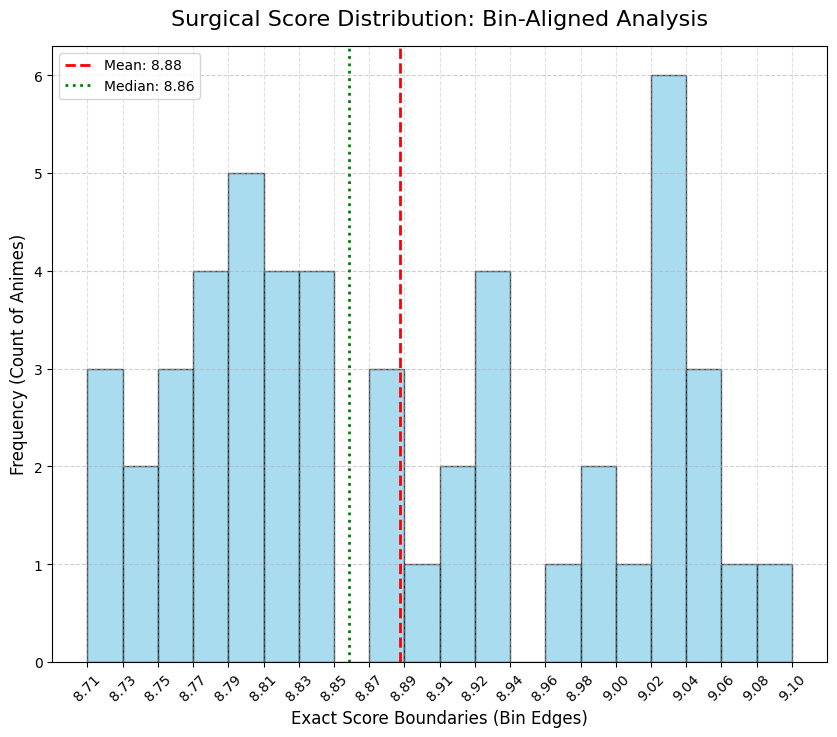

[3. 2. 3. 4. 5. 4. 4. 0. 3. 1. 2. 4. 0. 1. 2. 1. 6. 3. 1. 1.]
[8.71   8.7295 8.749  8.7685 8.788  8.8075 8.827  8.8465 8.866  8.8855
 8.905  8.9245 8.944  8.9635 8.983  9.0025 9.022  9.0415 9.061  9.0805
 9.1   ]


In [102]:

plt.figure(figsize=(10,8))

#  'bins' defines how many bars we want
counts, bin_edges, patches = plt.hist(df['Score'], bins=20 , color='skyblue', edgecolor='black',alpha=0.7)

# adding the grid 
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.grid(axis='x', linestyle='--', alpha=0.4)

# rotation so 8.71 of firts bin doesnt overlaps with 8.72 of starting of second bin 
# adding bin edges so we know each bar starts and ends at what value of score so we can get better insights 
# changed bins from 4 decimals to 2 decimals using formatted labels function , bins_edges give us numeric value and formatted_labels convert it into 2 decimal string..
formatted_labels = [f"{x:.2f}" for x in bin_edges]
plt.xticks(bin_edges,formatted_labels, rotation=45, fontsize=10)

# padding means adding space between title and graph box 
plt.title('Surgical Score Distribution: Bin-Aligned Analysis', fontsize=16, pad=15)
plt.xlabel('Exact Score Boundaries (Bin Edges)', fontsize=12)
plt.ylabel('Frequency (Count of Animes)', fontsize=12)



# addimg meam score and median score lines parallel to y axis i.e vertical line so we use plt.axvline 
mean_score = df['Score'].mean()
median_score = df['Score'].median()
plt.axvline(mean_score, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_score:.2f}')
plt.axvline(median_score, color='green', linestyle='dotted', linewidth=2, label=f'Median: {median_score:.2f}')

plt.legend()

plt.show()

print(counts)
print(bin_edges)